In [1]:
import numpy as np                                     # linear algebra
import pandas as pd                                    # data processing, CSV file I/O (e.g. pd.read_csv)
import copy                                            #to copy list
from sklearn.model_selection import train_test_split   #to split dataset into train and test set
from sklearn.svm import SVC                            #to create svc instance
from sklearn.metrics import classification_report      #to create report for precision,recall,f1-score,accuracy
from sklearn import metrics                            #to get accuracy
from sklearn.model_selection import GridSearchCV
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv #to optimise the hyper-parameter


DATA LOAD

In [2]:
df = pd.read_csv(r"H:\\THESIS\\DATASET\\2022-08-03-ss.cleaned.csv")
df.head()

,pdb_id,chain_code,seq,sst8,sst3,len,has_nonstd_aa
0,1A30,C,EDL,CBC,CEC,3,False
1,1B05,B,KCK,CBC,CEC,3,False
2,1B0H,B,KAK,CBC,CEC,3,False
3,1B1H,B,KFK,CBC,CEC,3,False
4,1B2H,B,KAK,CBC,CEC,3,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 477153 entries, 0 to 477152
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   pdb_id         477153 non-null  object
 1   chain_code     477153 non-null  object
 2   seq            477153 non-null  object
 3   sst8           477153 non-null  object
 4   sst3           477153 non-null  object
 5   len            477153 non-null  int64 
 6   has_nonstd_aa  477153 non-null  bool  
dtypes: bool(1), int64(1), object(5)
memory usage: 22.3+ MB


# **Data processing**

The PDB dataset is opened and processed using the python programming language. The 'seq' column has the primary sequence of protein and the 'sst8' has the seconday sequence of protein . The max length of any sequence set to 128 .
hasnonstdaa: whether the peptide contains nonstandard amino acids (B, O, U, X, or Z).
So those sequences are only taken which don't have nonstandard amino acids .

In [4]:
maxlen_seq = 128
input_seqs, target_seqs = df[['seq', 'sst3']][(df.len <= maxlen_seq) & (~df.has_nonstd_aa)].values.T
#input_grams = seq2ngrams(input_seqs)
print(input_seqs[0:5])
print(input_seqs.size)

['EDL' 'KCK' 'KAK' 'KFK' 'KAK']
103801


see the target sequence(secondary structure) and it's size .

In [5]:
print(target_seqs[0:5])
print(target_seqs.size)

['CEC' 'CEC' 'CEC' 'CEC' 'CEC']
103801


# **Looking for incomplete data**

Check the data whether there are differences in the number of characters of the primary structure and secondary structure (because the prediction of the secondary structure of the protein is included in the sequence labeling problem, it is certain that the number of characters of the primary structure and secondary structure is always the same)

In [6]:
for row in range(len(target_seqs)):
    secondary_lenth = len(target_seqs[row])
    primary_lenth = len(input_seqs[row])
    
    if(secondary_lenth != primary_lenth):
        print("(",row,") Secondary_Structure ->", target_seqs[row]," Primary_Structure -> ",input_seqs[row])

print("OKAY")

OKAY


Find the total sequence of primary structure and secondary structure to find out if there is no anomaly .

In [7]:
secondary_count = 0
primary_count = 0
for row in range(len(target_seqs)):
    secondary_lenth = len(target_seqs[row])
    primary_lenth = len(input_seqs[row])
    secondary_count = secondary_count + secondary_lenth
    primary_count = primary_count + primary_lenth
    if(secondary_lenth != primary_lenth):
        print("(",row,") Secondary_Structure ->", target_seqs[row]," Primary_Structure -> ",input_seqs[row])

print("count of secondary structure : ",secondary_count)
print("count of primary structure : ",primary_count)

count of secondary structure :  8386644
count of primary structure :  8386644


# **Orthogonal Encoding - Target Labeling**

Every primary and secondary structure data is split so that it can be encoded into orthogonal form

**Split function**<br>
split the string sequence into character array .<br>
input -> string <br>
output -> array of character

In [8]:
def split(sequence):
    return [char for char in sequence]

input_seqs is 2D array which has string in each row. Make it character array in each row .<br>
primary structure from input_seqs go to primary_split .<br>
secondary structure from target_seqs go to secondary_split .

In [9]:
primary_split = []
secondary_split = []
for row in range(int(len(target_seqs)/40)):
    primary_split.append(split(input_seqs[row]))
    secondary_split.append(split(target_seqs[row]))


The results of the split primary and secondary structure of the protein are then converted into orthogonal encoding and target labeling. A switch case snippet for each amino acid in the primary structure of a protein as follows .<br>
Secondary structure character represent ->
1. H= α-helix
2. C= Loops and irregular elements
3. E= β-strand
4. B= β-bridge
5. G= 3-helix
6. I= π-helix
7. T= Turn
8. S= Bend

In [10]:
def orthogonal_primary(arg):
    switch = {
        'A' : np.array([1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]),  # 20 amino acids
        'C' : np.array([0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]),
        'E' : np.array([0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]),
        'D' : np.array([0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]),
        'G' : np.array([0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]),
        'F' : np.array([0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0]),
        'I' : np.array([0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0]),
        'H' : np.array([0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0]),
        'K' : np.array([0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0]),
        'M' : np.array([0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0]),
        'L' : np.array([0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0]),
        'N' : np.array([0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0]),
        'Q' : np.array([0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0]),
        'P' : np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0]),
        'S' : np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0]),
        'R' : np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0]),
        'T' : np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0]),
        'W' : np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0]),
        'V' : np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0]),
        'Y' : np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1])
    }

    return switch.get(arg)

def orthogonal_secondary(arg):
    switch = {
        'H' : 0,                    # H= α-helix
        'C' : 1,                    # C= Loops and irregular elements
        'E' : 2,                    # E= β-strand
        'B' : 3,                    # B= β-bridge
        'G' : 4,                    # G= 3-helix
        'I' : 5,                    # I= π-helix
        'T' : 6,                    # T= Turn
        'S' : 7                     # S= Bend
    }

    return switch.get(arg)

For each character of primary structure and secondary structure use onehot key in the 20 amino acid .<br>
In secondary structure encode the 8 classification using 0-7 integer .

In [11]:
for row in range(len(primary_split)):
    sequence = primary_split[row]
    for col in range(len(sequence)):
        #print(sequence[col])
        sequence[col] = orthogonal_primary(sequence[col])
        #print(sequence[col])

In [12]:
for row in range(len(secondary_split)):
    sequenceS = secondary_split[row]
    for col in range(len(sequenceS)):
        sequenceS[col] = orthogonal_secondary(sequenceS[col])

In [13]:
primary_split[0:5]

[[array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])],
 [array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])],
 [array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])],
 [array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])],
 [array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  

In [14]:
secondary_split[0:5]

[[1, 2, 1], [1, 2, 1], [1, 2, 1], [1, 2, 1], [1, 2, 1]]

# Make the Graph

**graph_sum2**<br>
this function take input 2 node (amino acid character's onehot key) and return the sum of 2 node .<br>
**graph_sum3**<br>
this function take input 3 node (amino acid character's onehot key) and return the sum of 3 node .

In [15]:
def graph_sum2(seq1,seq2):
    result = [None]*len(seq1)
    for col in range(len(seq1)):
        result[col] =  seq1[col]+seq2[col]
    return result


def graph_sum3(seq1,seq2,seq3):
    result = [None]*len(seq1)
    for col in range(len(seq1)):
        result[col] =  seq1[col]+seq2[col]+seq3[col]
    return result

**Graph of primary structure**<br>
The primary structure is a linear string of character/amino acid(node) .<br>
Example : ***ABBA***<br>
In Graph Neural Network , we take each node and sum the information value of it's adjacent node. As a result we find a new value for each node which is dependable for it's adjacent nodes .<br>

the border node will use graph_sum2 function as it has only 1 adjacent node and the rest will use graph_sum3 function .

In [16]:
graph_input = copy.deepcopy(primary_split)
for row in range(len(primary_split)):
    sequence = primary_split[row]
    graph_input[row][0]=graph_sum2(sequence[0],sequence[1])
    graph_input[row][len(sequence)-1]=graph_sum2(sequence[len(sequence)-1],sequence[len(sequence)-2])
    for col in range(1,len(sequence)-1):
        graph_input[row][col] = graph_sum3(sequence[col-1],sequence[col],sequence[col+1])

graph_input[0:5]

[[[np.int64(0),
   np.int64(0),
   np.int64(1),
   np.int64(1),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0)],
  [np.int64(0),
   np.int64(0),
   np.int64(1),
   np.int64(1),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(1),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0)],
  [np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(1),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(1),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0)]],
 [[np.int64(0),
   np.int64(1),
   n

Make the secondary structure in a array of data using targetY function .

In [17]:
def targetY(data_list):
    Y = []
    for i in range(len(data_list)):
        for j  in range(len(data_list[i])):
            Y.append(data_list[i][j])
    return Y

In [18]:
y_label = targetY(secondary_split)

In [19]:
print(len(y_label))
print(y_label[0:5])

18642
[1, 2, 1, 1, 2]


In [20]:
def window_padding_data(size, sequence):
    num = int(size/2)
    #print("initial :",sequence[0])
    #print("")
    zeros = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    for i in range(len(sequence)):
        for j in range(num):
            sequence[i].append(zeros)
            sequence[i].insert(0, zeros)
            #print(sequence[i])
            #print("")

    X = []
    temp = []

    for k in range(len(sequence)):
        #print(sequence[k])
        for l in range(len(sequence[k])-(size-1)):
            temp = sequence[k][l:l+size]
           # print(temp)
            X.append(temp)
            temp = []

    return X

In [ ]:
X = window_padding_data(11,graph_input)
len(X)
X[0:5]

[[array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  [np.int64(0),
   np.int64(0),
   np.int64(1),
   np.int64(1),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0)],
  [np.int64(0),
   np.int64(0),
   np.int64(1),
   np.int64(1),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(1),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0),
   np.int64(0)],
  [

In [22]:
np.set_printoptions(threshold=np.inf)
X = np.array(X)
y_label = np.array(y_label)
X = X.reshape(len(X),11*20)
print(X[0:5])

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1
  0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0
  0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 

In [23]:
#split the dataset into train set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y_label, test_size = 0.30,random_state=54)

In [24]:
X_train[0]

array([0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [25]:
y_train[len(y_train)-1]

np.int64(1)

In [26]:
from imblearn.over_sampling import SMOTE


In [27]:
smote = SMOTE(random_state=54)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [29]:
'''from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Define parameter grids for both models
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

param_grid_rf = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV for KNN
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, refit=True, verbose=3, scoring='accuracy')

# Fit the model for KNN grid search
grid_knn.fit(X_train, y_train)

# Print the best parameters for KNN
print("Best parameters for KNN: ", grid_knn.best_params_)

# Make predictions for KNN
grid_knn_predictions = grid_knn.predict(X_test)

# Print classification report for KNN
print("Classification report for KNN:")
print(classification_report(y_test, grid_knn_predictions))

# Print the best estimator for KNN
print("Best estimator for KNN: ", grid_knn.best_estimator_)

# Initialize GridSearchCV for Random Forest
grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, refit=True, verbose=3, scoring='accuracy')

# Fit the model for Random Forest grid search
grid_rf.fit(X_train, y_train)

# Print the best parameters for Random Forest
print("Best parameters for Random Forest: ", grid_rf.best_params_)

# Make predictions for Random Forest
grid_rf_predictions = grid_rf.predict(X_test)

# Print classification report for Random Forest
print("Classification report for Random Forest:")
print(classification_report(y_test, grid_rf_predictions))

# Print the best estimator for Random Forest
print("Best estimator for Random Forest: ", grid_rf.best_estimator_)'''

'from sklearn.model_selection import GridSearchCV\nfrom sklearn.neighbors import KNeighborsClassifier\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.metrics import classification_report\n\n# Define parameter grids for both models\nparam_grid_knn = {\n    \'n_neighbors\': [3, 5, 7, 9, 11],\n    \'weights\': [\'uniform\', \'distance\'],\n    \'algorithm\': [\'auto\', \'ball_tree\', \'kd_tree\', \'brute\']\n}\n\nparam_grid_rf = {\n    \'n_estimators\': [50, 100, 150, 200],\n    \'max_depth\': [10, 20, 30, None],\n    \'min_samples_split\': [2, 5, 10],\n    \'min_samples_leaf\': [1, 2, 4]\n}\n\n# Initialize GridSearchCV for KNN\ngrid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, refit=True, verbose=3, scoring=\'accuracy\')\n\n# Fit the model for KNN grid search\ngrid_knn.fit(X_train, y_train)\n\n# Print the best parameters for KNN\nprint("Best parameters for KNN: ", grid_knn.best_params_)\n\n# Make predictions for KNN\ngrid_knn_predictions = grid_knn.predic

In [30]:
k = KNeighborsClassifier(algorithm='brute', n_neighbors= 3, weights= 'distance')
k.fit(X_train, y_train)
y_pred = k.predict(X_test)
y_true = y_test
#    print("i = ",i,"acc = ",metrics.accuracy_score(y_test, y_pred))
print("KNN Accuracy = ",metrics.accuracy_score(y_test, y_pred)*100)
print(classification_report(y_true,y_pred))

KNN Accuracy =  92.79456463436439
              precision    recall  f1-score   support

           0       0.72      0.66      0.69       155
           1       0.95      0.96      0.96      4620
           2       0.81      0.80      0.81       818

    accuracy                           0.93      5593
   macro avg       0.83      0.81      0.82      5593
weighted avg       0.93      0.93      0.93      5593



In [31]:
from sklearn.metrics import confusion_matrix


In [32]:

# Get confidence scores
y_pred_proba = k.predict_proba(X_test)  # Probabilities for each class
y_pred = k.predict(X_test)  # Hard predictions

# Compute classification matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Example: Extract confidence scores for predictions
confidence_scores = y_pred_proba.max(axis=1)  # Max probability for each prediction
print("Confidence Scores:", confidence_scores[:100])  # Display first 10 scores
cs = 0
for i in range(len(confidence_scores)):
    cs = cs + confidence_scores[i]
print("Average Confidence Score: ",cs/len(confidence_scores))


Confidence Scores: [1.         1.         0.65300876 1.         1.         1.
 1.         0.66666667 0.5        1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         0.67379864 0.66054578
 1.         1.         0.66666667 1.         1.         1.
 1.         1.         1.         1.         0.66666667 0.66666667
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         0.68356903 1.
 1.         1.         1.         1.         1.         1.
 1.         1.         0.65838223 1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.       

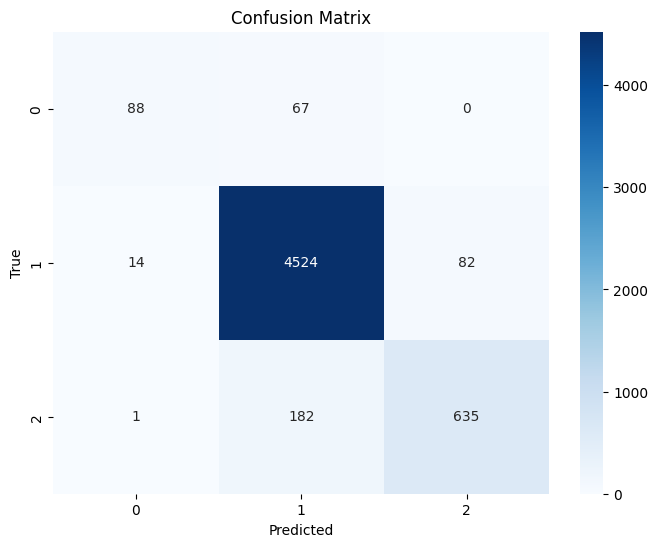

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns


# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])

# Adding labels and title
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

# Display the plot
plt.show()

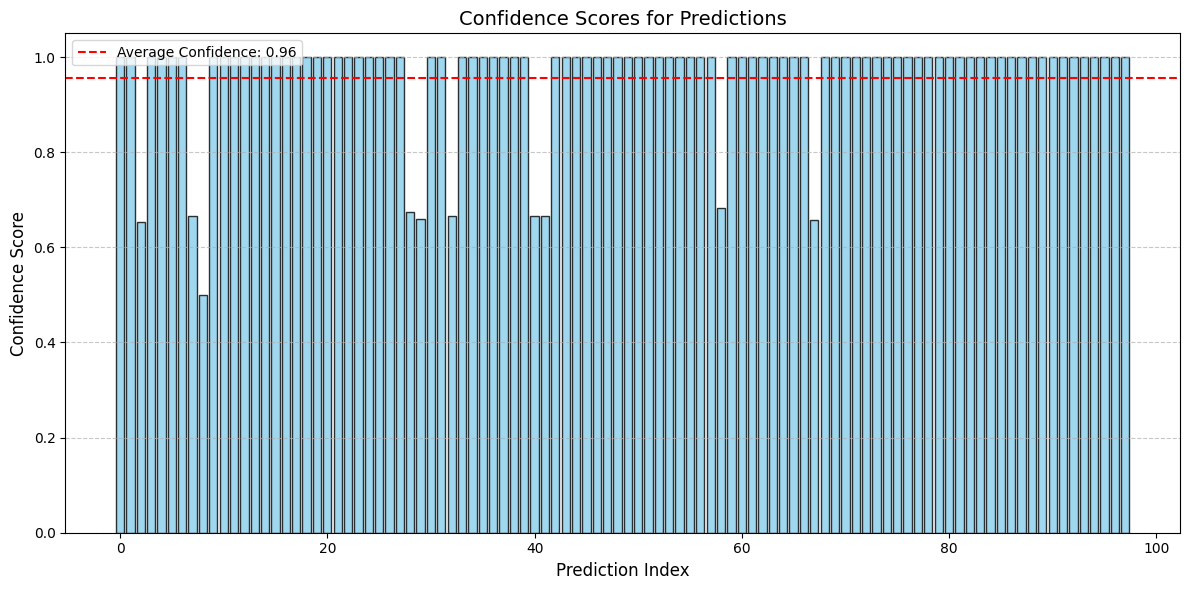

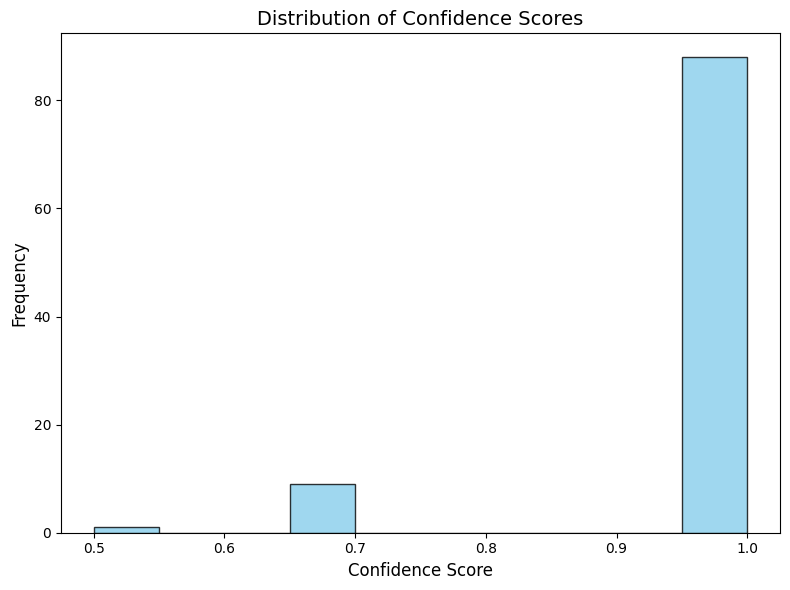

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Confidence scores data
confidence_scores = [
    1.0, 1.0, 0.65300876, 1.0, 1.0, 1.0, 1.0, 0.66666667, 0.5, 1.0, 1.0, 1.0, 
    1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 
    1.0, 0.67379864, 0.66054578, 1.0, 1.0, 0.66666667, 1.0, 1.0, 1.0, 1.0, 1.0, 
    1.0, 1.0, 0.66666667, 0.66666667, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 
    1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.68356903, 1.0, 1.0, 1.0, 1.0, 1.0, 
    1.0, 1.0, 1.0, 0.65838223, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 
    1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 
    1.0, 1.0, 1.0, 1.0, 1.0
]
average_confidence = 0.9563596567275522

# Bar chart for confidence scores
plt.figure(figsize=(12, 6))
plt.bar(range(len(confidence_scores)), confidence_scores, color='skyblue', edgecolor='black', alpha=0.8)

# Plot average confidence as a horizontal line
plt.axhline(y=average_confidence, color='red', linestyle='--', label=f'Average Confidence: {average_confidence:.2f}')

# Add labels and title
plt.xlabel('Prediction Index', fontsize=12)
plt.ylabel('Confidence Score', fontsize=12)
plt.title('Confidence Scores for Predictions', fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

# Histogram for confidence score distribution
plt.figure(figsize=(8, 6))
plt.hist(confidence_scores, bins=10, color='skyblue', edgecolor='black', alpha=0.8)

# Add labels and title
plt.xlabel('Confidence Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Confidence Scores', fontsize=14)

# Show the plot
plt.tight_layout()
plt.show()


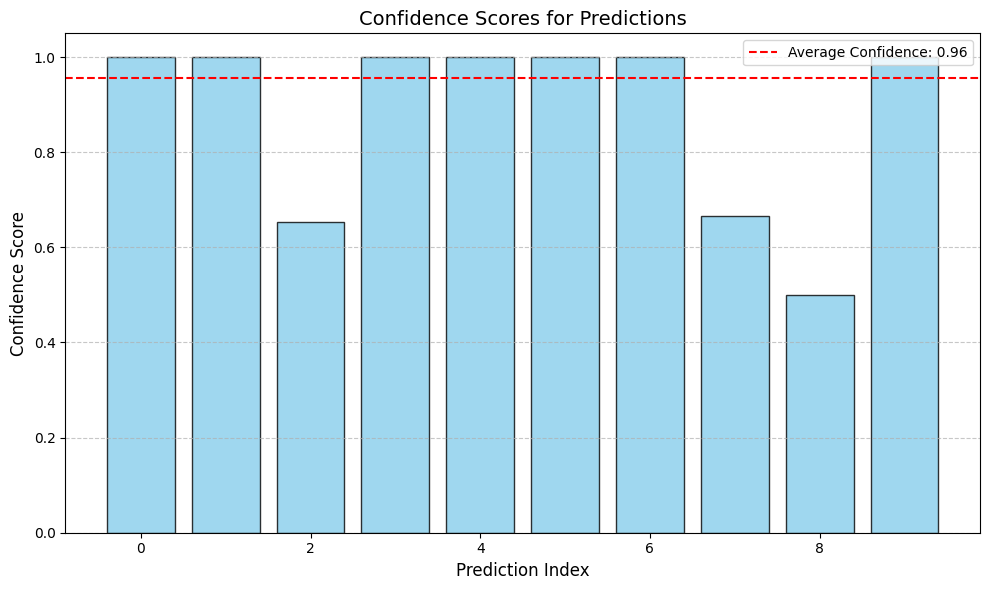

In [35]:
import matplotlib.pyplot as plt

# Confidence scores data
confidence_scores = [1.0, 1.0, 0.65300876, 1.0, 1.0, 1.0, 1.0, 0.66666667, 0.5, 1.0]
average_confidence = 0.9563596567275522

# Bar chart for confidence scores
plt.figure(figsize=(10, 6))
plt.bar(range(len(confidence_scores)), confidence_scores, color='skyblue', edgecolor='black', alpha=0.8)

# Plot average confidence as a horizontal line
plt.axhline(y=average_confidence, color='red', linestyle='--', label=f'Average Confidence: {average_confidence:.2f}')

# Add labels and title
plt.xlabel('Prediction Index', fontsize=12)
plt.ylabel('Confidence Score', fontsize=12)
plt.title('Confidence Scores for Predictions', fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


In [36]:
from sklearn.metrics import matthews_corrcoef

# MCC for the multiclass problem
mcc = matthews_corrcoef(y_test, y_pred)
print("Matthews Correlation Coefficient (MCC):", mcc)


Matthews Correlation Coefficient (MCC): 0.7533018831364763


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

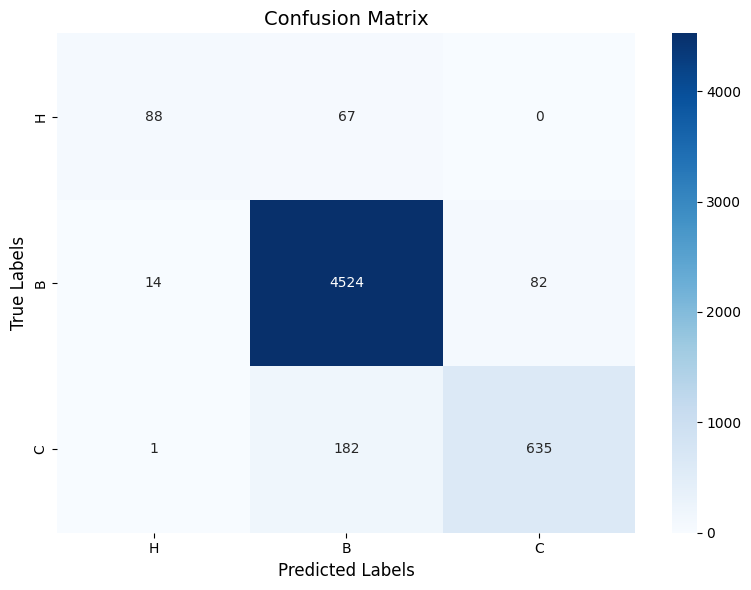

In [53]:
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['H', 'B', 'C'],
            yticklabels=['H', 'B', 'C'])

plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("True Labels", fontsize=12)
plt.tight_layout()
plt.show()

In [39]:
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix

In [40]:
rf = RandomForestClassifier(max_depth= None, min_samples_leaf=1, min_samples_split= 3, n_estimators= 100)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_true = y_test
#    print("i = ",i,"acc = ",metrics.accuracy_score(y_test, y_pred))
print("Accuracy = ",metrics.accuracy_score(y_test, y_pred)*100)
print(classification_report(y_true,y_pred))

Accuracy =  93.72429822993027
              precision    recall  f1-score   support

           0       0.85      0.56      0.68       155
           1       0.94      0.98      0.96      4620
           2       0.90      0.75      0.82       818

    accuracy                           0.94      5593
   macro avg       0.90      0.77      0.82      5593
weighted avg       0.94      0.94      0.93      5593



from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

In [41]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

In [42]:
meta_model = LogisticRegression()

# Stack KNN and RF together
stacking_model = StackingClassifier(estimators=[('knn', k), ('rf', rf)], final_estimator=meta_model)

# Create a pipeline with scaling and stacking
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('stacking', stacking_model)  # StackingClassifier as the final model
])

# Fit the pipeline
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

# Print classification report
print("Classification report for Stacking Classifier (KNN + RF):")
print(classification_report(y_test, y_pred))

Classification report for Stacking Classifier (KNN + RF):
              precision    recall  f1-score   support

           0       0.85      0.57      0.68       155
           1       0.95      0.98      0.96      4620
           2       0.89      0.78      0.83       818

    accuracy                           0.94      5593
   macro avg       0.90      0.77      0.82      5593
weighted avg       0.94      0.94      0.94      5593



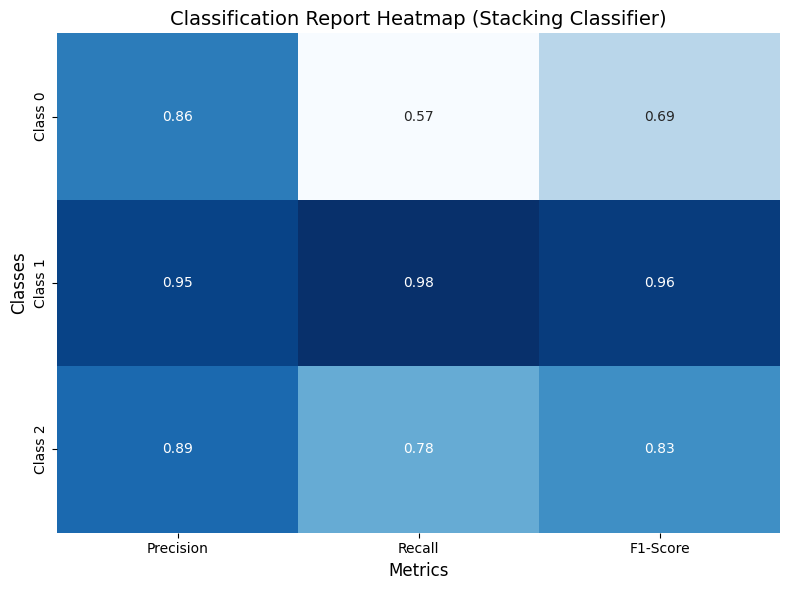

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Data from the classification report
classes = ['Class 0', 'Class 1', 'Class 2']
precision = [0.86, 0.95, 0.89]
recall = [0.57, 0.98, 0.78]
f1_score = [0.69, 0.96, 0.83]

# Create a DataFrame
report_data = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1_score
}, index=classes)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(report_data, annot=True, cmap="Blues", fmt=".2f", cbar=False)
plt.title("Classification Report Heatmap", fontsize=14)
plt.xlabel("Metrics", fontsize=12)
plt.ylabel("Classes", fontsize=12)
plt.tight_layout()
plt.show()


In [44]:
EPSILON = 1e-5
print('Mean Absolute Error(MAE):', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error(MSE):', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error(RMSE):', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('Relative Absolute Error(RAE):', np.sum(np.abs(y_test - y_pred)) / (np.sum(np.abs(y_test - np.mean(y_test))) + EPSILON))
print('Root Relative Squared Error(RRSE):', np.sqrt(np.sum(np.square(y_test - y_pred)) / np.sum(np.square(y_test - np.mean(y_test)))))

Mean Absolute Error(MAE): 0.062041838011800465
Mean Squared Error(MSE): 0.062399427856248885
Root Mean Squared Error(RMSE): 0.2497987747292786
Relative Absolute Error(RAE): 0.24062684261094705
Root Relative Squared Error(RRSE): 0.624661942149261


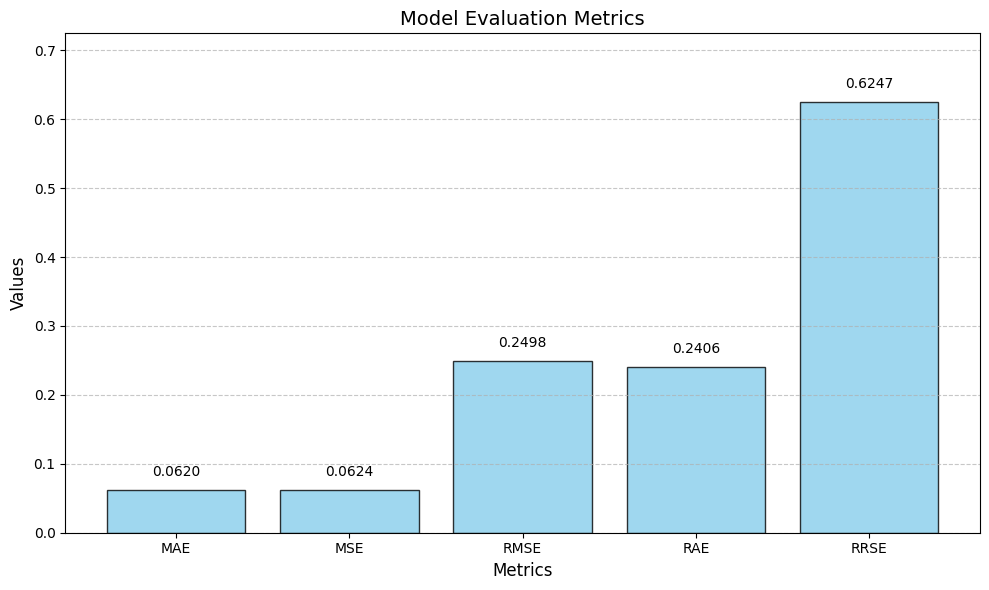

In [45]:
# Metrics data
metrics_labels = ['MAE', 'MSE', 'RMSE', 'RAE', 'RRSE']
values = [
    metrics.mean_absolute_error(y_test, y_pred),
    metrics.mean_squared_error(y_test, y_pred),
    np.sqrt(metrics.mean_squared_error(y_test, y_pred)),
    np.sum(np.abs(y_test - y_pred)) / (np.sum(np.abs(y_test - np.mean(y_test))) + EPSILON),
    np.sqrt(np.sum(np.square(y_test - y_pred)) / np.sum(np.square(y_test - np.mean(y_test))))
]

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(metrics_labels, values, color='skyblue', alpha=0.8, edgecolor='black')

# Add labels and title
plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.title('Model Evaluation Metrics', fontsize=14)

# Annotate the bars with values
for i, value in enumerate(values):
    plt.text(i, value + 0.02, f'{value:.4f}', ha='center', fontsize=10)

# Set y-axis limits for better visualization
plt.ylim(0, max(values) + 0.1)

# Show gridlines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


In [46]:
# SOV: Sum of Absolute Variations
sov = np.sum(np.abs(y_test - y_pred))

print("Sum of Variations (SOV):", sov)


Sum of Variations (SOV): 347


In [47]:
# Calculate total variation
total_variation = np.sum(np.abs(y_test - np.mean(y_test)))

# Calculate SOV accuracy
sov_accuracy = 1 - (sov / (total_variation))  # Avoid division by zero

print("SOV Accuracy:", sov_accuracy)

SOV Accuracy: 0.7593731557204282


In [48]:
# Add SOV to metrics and values
metrics_labels.append('SOV')
values.append(sov)


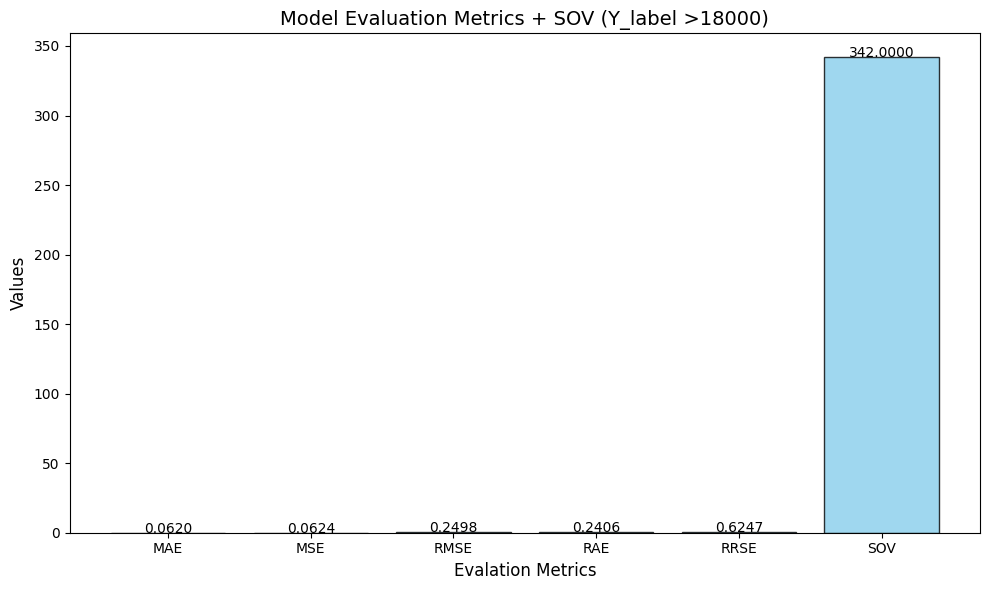

In [49]:
# Updated metrics data with SOV
metrics_labels = ['MAE', 'MSE', 'RMSE', 'RAE', 'RRSE', 'SOV']
values = [
    metrics.mean_absolute_error(y_test, y_pred),
    metrics.mean_squared_error(y_test, y_pred),
    np.sqrt(metrics.mean_squared_error(y_test, y_pred)),
    np.sum(np.abs(y_test - y_pred)) / (np.sum(np.abs(y_test - np.mean(y_test))) + EPSILON),
    np.sqrt(np.sum(np.square(y_test - y_pred)) / np.sum(np.square(y_test - np.mean(y_test)))),
    342  # SOV value
]

# Visualization (Bar Chart)
plt.figure(figsize=(10, 6))
plt.bar(metrics_labels, values, color='skyblue', alpha=0.8, edgecolor='black')

# Add labels and title
plt.xlabel('Evalation Metrics', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.title('Model Evaluation Metrics + SOV (Y_label >18000)', fontsize=14)

# Annotate the bars with values
for i, value in enumerate(values):
    plt.text(i, value + 0.02, f'{value:.4f}', ha='center', fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()


In [50]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import numpy as np

In [51]:

def evaluate_model(cv):
    scores = cross_val_score(svc, X, y_label, scoring='accuracy', cv=cv, n_jobs=-1)
    return np.mean(scores), scores.min(), scores.max()


In [52]:
def evaluate_model(cv, X, y):
    scores = cross_val_score(pipeline, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
    return np.mean(scores), scores.min(), scores.max()

# Example usage with dataset
folds = [3, 5, 10,15,20,25,30]  # Different K-fold splits
means = []

for k in folds:
    cv = KFold(n_splits=k, shuffle=True, random_state=1)
    k_mean, k_min, k_max = evaluate_model(cv, X_train, y_train)  # Use X_train, y_train
    print(f'> folds={k}, accuracy={k_mean:.3f} ({k_min:.3f}, {k_max:.3f})')
    means.append(k_mean)

# Fit on full training set and evaluate on test set
y_pred = pipeline.predict(X_test)
print("\nClassification report for Stacking Classifier (KNN + RF):")
print(classification_report(y_test, y_pred))


> folds=3, accuracy=0.922 (0.916, 0.928)
> folds=5, accuracy=0.926 (0.919, 0.930)
> folds=10, accuracy=0.929 (0.920, 0.935)


KeyboardInterrupt: 

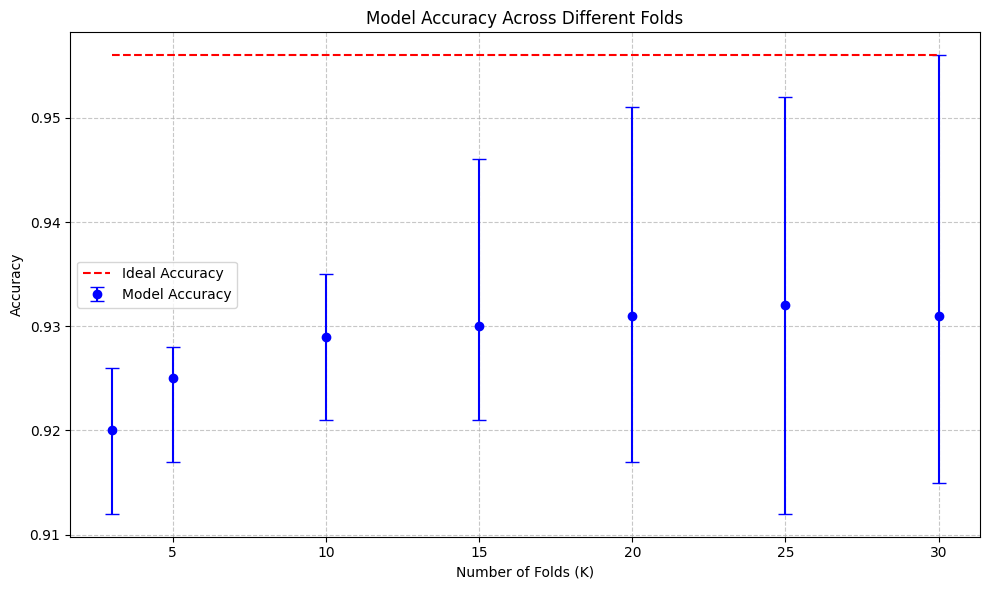

In [52]:
# Updated data based on the provided results
folds = [3, 5, 10, 15, 20, 25, 30]  # Number of folds
means = [0.920, 0.925, 0.929, 0.930, 0.931, 0.932, 0.931]  # Mean accuracy
mins = [0.912, 0.917, 0.921, 0.921, 0.917, 0.912, 0.915]  # Minimum accuracy
maxs = [0.926, 0.928, 0.935, 0.946, 0.951, 0.952, 0.956]  # Maximum accuracy

# Compute y-errors for error bars
y_err = [np.array(means) - np.array(mins), np.array(maxs) - np.array(means)]

# Plot the error bars for accuracy
plt.figure(figsize=(10, 6))
plt.errorbar(folds, means, yerr=y_err, fmt='o', label='Model Accuracy', capsize=5, color='b')

# Plot the ideal case (assumed highest observed accuracy for visualization)
ideal = max(maxs)
plt.plot(folds, [ideal for _ in range(len(folds))], color='r', linestyle='--', label='Ideal Accuracy')

# Add labels and title
plt.xlabel('Number of Folds (K)')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Across Different Folds')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()
